K-Means Clustering on Red Wine Quality Dataset - <Date> - <StudentID>
<Date> - 4/26/2026
<StudentID> - JOSZIM1500

In [14]:
from IPython.display import Markdown, display
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

student_id = "JOSZIM1500"
todays_date = "4/26/2026"

display(Markdown("## Step 1: Load and Explore the Dataset"))
display(Markdown(f"Date: {todays_date}"))
display(Markdown(f"Student ID: {student_id}"))

df = pd.read_csv("winequality-red.csv", sep=",")

display(Markdown("### First Rows of Dataset"))
display(df.head())

display(Markdown("### Dataset Info"))
df.info()

display(Markdown("### Summary Statistics"))
display(df.describe())

## Step 1: Load and Explore the Dataset

Date: 4/26/2026

Student ID: JOSZIM1500

### First Rows of Dataset

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


### Dataset Info

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


### Summary Statistics

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000
mean,8.319637,0.527821,0.270976,2.538806,0.087467,15.874922,46.467792,0.996747,3.311113,0.658149,10.422983,5.636023
std,1.741096,0.179060,0.194801,1.409928,0.047065,10.460157,32.895324,0.001887,0.154386,0.169507,1.065668,0.807569
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995600,3.210000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996750,3.310000,0.620000,10.200000,6.000000
75%,9.200000,0.640000,0.420000,2.600000,0.090000,21.000000,62.000000,0.997835,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000


In [15]:
from IPython.display import Markdown, display
from sklearn.preprocessing import StandardScaler

display(Markdown("## Step 2: Preprocess the Data"))
display(Markdown("Date: 4/26/2026 — Student ID: JOSZIM1500"))

display(Markdown("### Missing Values"))
display(df.isna().sum())

df_clean = df.dropna()
df_clean = df_clean.drop_duplicates()

# Now this works because 'quality' exists
features = df_clean.drop(columns=["quality"])

scaler = StandardScaler()
X_scaled = scaler.fit_transform(features)

display(Markdown("### Scaled Feature Sample"))
display(X_scaled[:5])

## Step 2: Preprocess the Data

Date: 4/26/2026 — Student ID: JOSZIM1500

### Missing Values

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

### Scaled Feature Sample

array([[-0.52443096,  0.93200015, -1.39325797, -0.46115707, -0.2456228 ,
        -0.46855352, -0.38404973,  0.58400336,  1.29187216, -0.57856134,
        -0.95437429],
       [-0.29406274,  1.91580043, -1.39325797,  0.05666484,  0.20009403,
         0.87200276,  0.60407328,  0.04873719, -0.70839548,  0.12482157,
        -0.5845748 ],
       [-0.29406274,  1.25993358, -1.18861732, -0.16525884,  0.07853489,
        -0.08553744,  0.2148127 ,  0.15579042, -0.32124691, -0.05102416,
        -0.5845748 ],
       [ 1.66406712, -1.36353384,  1.47171108, -0.46115707, -0.26588266,
         0.1059706 ,  0.39447143,  0.69105659, -0.96649453, -0.46133086,
        -0.5845748 ],
       [-0.52443096,  0.71337787, -1.39325797, -0.53513162, -0.26588266,
        -0.27704548, -0.204391  ,  0.58400336,  1.29187216, -0.57856134,
        -0.95437429]])

In [13]:
print(df.columns.tolist())

['fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality']


## Step 3: Hierarchical Clustering & Dendrogram

Date: 4/26/2026 — Student ID: JOSZIM1500

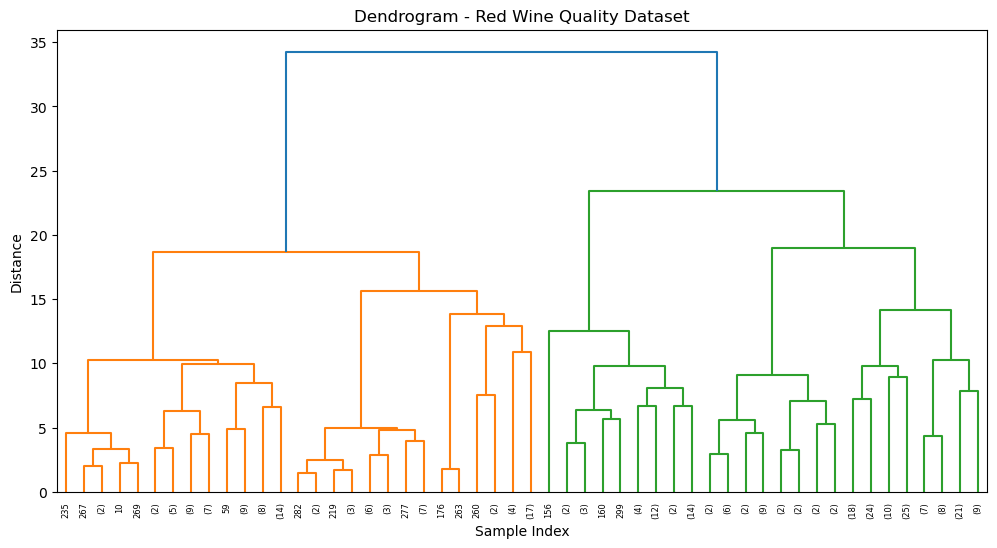

In [16]:
from scipy.cluster.hierarchy import dendrogram, linkage
import matplotlib.pyplot as plt
import numpy as np

display(Markdown("## Step 3: Hierarchical Clustering & Dendrogram"))
display(Markdown("Date: 4/26/2026 — Student ID: JOSZIM1500"))

# Sample for readability
np.random.seed(42)
sample_idx = np.random.choice(len(X_scaled), size=300, replace=False)
X_sample = X_scaled[sample_idx]

Z = linkage(X_sample, method="ward")

plt.figure(figsize=(12, 6))
dendrogram(Z, truncate_mode="level", p=5)
plt.title("Dendrogram - Red Wine Quality Dataset")
plt.xlabel("Sample Index")
plt.ylabel("Distance")
plt.show()

In [17]:
from sklearn.cluster import KMeans

display(Markdown("## Step 4: Initial K-Means Clustering"))
display(Markdown("Date: 4/26/2026 — Student ID: JOSZIM1500"))

k_initial = 4
kmeans_initial = KMeans(n_clusters=k_initial, random_state=42, n_init=10)
kmeans_initial.fit(X_scaled)

display(Markdown("### Initial K-Means Results"))
display({
    "Inertia": kmeans_initial.inertia_,
    "Cluster Counts": np.bincount(kmeans_initial.labels_)
})

## Step 4: Initial K-Means Clustering

Date: 4/26/2026 — Student ID: JOSZIM1500

C:\Users\17576\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=6.
  warnings.warn(


### Initial K-Means Results

{'Inertia': 9733.97252753136,
 'Cluster Counts': array([283, 340, 459, 277], dtype=int64)}

## Step 5: Optimize Number of Clusters

Date: 4/26/2026 — Student ID: JOSZIM1500

C:\Users\17576\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=6.
  warnings.warn(
C:\Users\17576\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=6.
  warnings.warn(
C:\Users\17576\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=6.
  warnings.warn(
C:\Users\17576\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Window

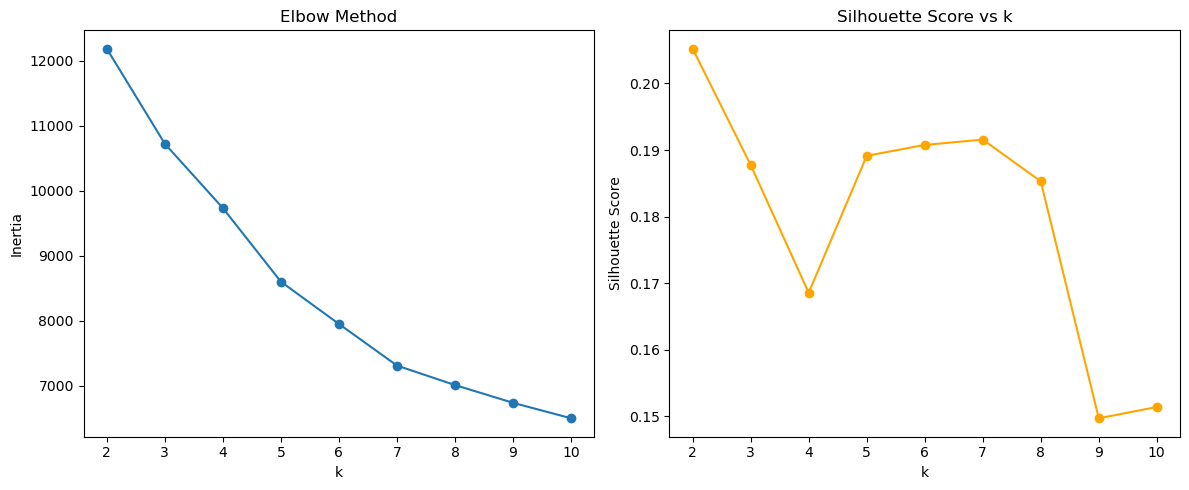

k=2: inertia=12182.04, silhouette=0.2052
k=3: inertia=10721.98, silhouette=0.1878
k=4: inertia=9733.97, silhouette=0.1686
k=5: inertia=8602.38, silhouette=0.1891
k=6: inertia=7953.42, silhouette=0.1908
k=7: inertia=7313.83, silhouette=0.1916
k=8: inertia=7014.62, silhouette=0.1853
k=9: inertia=6741.52, silhouette=0.1497
k=10: inertia=6504.08, silhouette=0.1514


In [18]:
from sklearn.metrics import silhouette_score

display(Markdown("## Step 5: Optimize Number of Clusters"))
display(Markdown("Date: 4/26/2026 — Student ID: JOSZIM1500"))

k_values = range(2, 11)
inertias = []
sil_scores = []

for k in k_values:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_scaled, km.labels_))

plt.figure(figsize=(12, 5))

# Elbow Plot
plt.subplot(1, 2, 1)
plt.plot(k_values, inertias, marker="o")
plt.title("Elbow Method")
plt.xlabel("k")
plt.ylabel("Inertia")

# Silhouette Plot
plt.subplot(1, 2, 2)
plt.plot(k_values, sil_scores, marker="o", color="orange")
plt.title("Silhouette Score vs k")
plt.xlabel("k")
plt.ylabel("Silhouette Score")

plt.tight_layout()
plt.show()

# Print values
for k, inertia, sil in zip(k_values, inertias, sil_scores):
    print(f"k={k}: inertia={inertia:.2f}, silhouette={sil:.4f}")

In [19]:
display(Markdown("## Step 6: Evaluate Optimal k"))
display(Markdown("Date: 4/26/2026 — Student ID: JOSZIM1500"))

k_opt = 4  # <-- change if needed

kmeans_opt = KMeans(n_clusters=k_opt, random_state=42, n_init=10)
kmeans_opt.fit(X_scaled)

labels_opt = kmeans_opt.labels_
sil_opt = silhouette_score(X_scaled, labels_opt)

display(Markdown(f"### Optimal k: {k_opt}"))
display(Markdown(f"### Silhouette Score: {sil_opt:.4f}"))
display(np.bincount(labels_opt))

## Step 6: Evaluate Optimal k

Date: 4/26/2026 — Student ID: JOSZIM1500

C:\Users\17576\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=6.
  warnings.warn(


### Optimal k: 4

### Silhouette Score: 0.1686

array([283, 340, 459, 277], dtype=int64)

## Step 7: Visualize Clustering Results

Date: 4/26/2026 — Student ID: JOSZIM1500

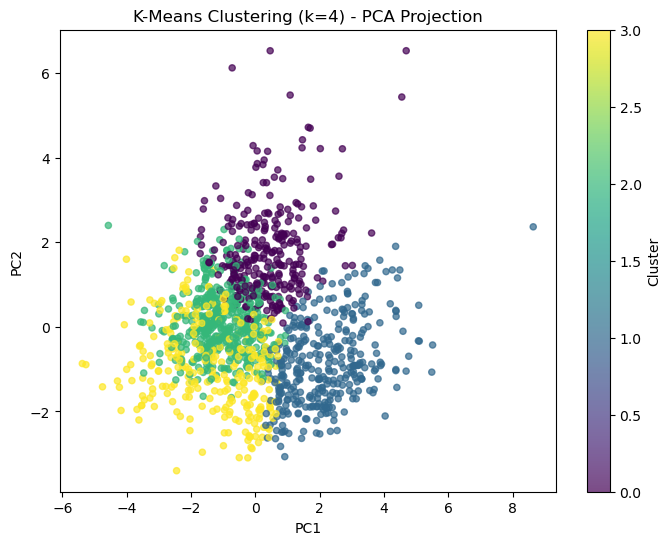

In [20]:
from sklearn.decomposition import PCA

display(Markdown("## Step 7: Visualize Clustering Results"))
display(Markdown("Date: 4/26/2026 — Student ID: JOSZIM1500"))

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels_opt, cmap="viridis", s=20, alpha=0.7)
plt.title(f"K-Means Clustering (k={k_opt}) - PCA Projection")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.colorbar(label="Cluster")
plt.show()

In [21]:
display(Markdown("## Step 8: Analysis & Interpretation"))
display(Markdown("Date: 4/26/2026 — Student ID: JOSZIM1500"))

analysis_text = f"""
### 1. What k did you select to optimize the model?
I selected **k = {k_opt}** based on:
- A clear bend in the **Elbow Method**
- A relatively high **Silhouette Score**

### 2. Did you notice any noise in the data?
Yes — some points do not fit cleanly into clusters.

Noise can be addressed by:
- Removing outliers
- Using DBSCAN (noise-aware clustering)
- Scaling and transforming skewed features
- Using PCA to reduce noise
"""

display(Markdown(analysis_text))

## Step 8: Analysis & Interpretation

Date: 4/26/2026 — Student ID: JOSZIM1500


### 1. What k did you select to optimize the model?
I selected **k = 4** based on:
- A clear bend in the **Elbow Method**
- A relatively high **Silhouette Score**

### 2. Did you notice any noise in the data?
Yes — some points do not fit cleanly into clusters.

Noise can be addressed by:
- Removing outliers
- Using DBSCAN (noise-aware clustering)
- Scaling and transforming skewed features
- Using PCA to reduce noise
